# Greenness and brownness per NUTS region

Scores each PNG from the Sentinel-2 pipeline on:
- **Green %** — fraction of opaque land pixels falling in HSV's green range
- **Brown %** — fraction falling in the brown/dry-vegetation range
- **Index** — green % minus brown %, one number ranging from -100 (fully brown) to +100 (fully green)

Everything keys off the same `(nuts_id, year, month, level)` DataFrame as the average-colour
notebook — filter by any of them.

**Method note:** HSV colour-space thresholding is standard for vegetation detection in
Python, much more meaningful than RGB averaging (which mixes green + red into brown and
loses the signal). This is what MODIS-derived greenness proxies use too.


## 1. Setup

In [1]:
import os
import re
import numpy as np
import pandas as pd
import geopandas as gpd
import cv2 as cv

import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
OUTPUT_DIR = "output"
NUTS_GEOJSON = "NUTS_RG_20M_2024_4326.geojson"
CSV_OUT_DIR = "output/0_analysis_csv"
os.makedirs(CSV_OUT_DIR, exist_ok=True)

nuts_gdf = gpd.read_file(NUTS_GEOJSON)

## 2. HSV colour ranges

OpenCV's HSV: **Hue 0–179** (not 0–255, not 0–359), saturation and value 0–255.

- **Green:** hue 30–90 covers yellow-green through blue-green. Saturation/value ≥ 40 to
  exclude near-grey pixels that would be washed-out sky/haze
- **Brown:** hue 10–25 covers orange-brown through amber. Same S/V floor

Tune the ranges by eyeballing masks with `visualize_mask()` below.

In [3]:
GREEN_HSV_LO = np.array([30, 40, 40])
GREEN_HSV_HI = np.array([90, 255, 255])

BROWN_HSV_LO = np.array([10, 40, 40])
BROWN_HSV_HI = np.array([25, 255, 255])

## 3. Index the images

Same walker as the average-colour notebook. Each row is one PNG with its NUTS ID,
level, year, and month.

In [4]:
def scan_images(output_dir=OUTPUT_DIR):
    rows = []
    for region in os.listdir(output_dir):
        region_path = os.path.join(output_dir, region)
        if not os.path.isdir(region_path):
            continue
        for year_str in os.listdir(region_path):
            year_path = os.path.join(region_path, year_str)
            if not os.path.isdir(year_path):
                continue
            for fname in os.listdir(year_path):
                m = re.search(r"_(\d{4})-(\d{2})-\d{2}\.png$", fname)
                if not m:
                    continue
                nuts_id = region.split("_", 1)[0]
                rows.append({
                    "region": region,
                    "nuts_id": nuts_id,
                    "level": len(nuts_id) - 2,
                    "year": int(m.group(1)),
                    "month": int(m.group(2)),
                    "path": os.path.join(year_path, fname),
                })
    return pd.DataFrame(rows)


index_df = scan_images()
print(f"Found {len(index_df)} images across {index_df['nuts_id'].nunique()} regions")
print("Levels:", sorted(index_df["level"].unique()))
index_df.head()

Found 1362 images across 51 regions
Levels: [0, 1, 2]


,region,nuts_id,level,year,month,path
0,LI_Liechtenstein 14.04.41,LI,0,2022,7,output/LI_Liechtenstein 14.04.41/2022/LI_Liech...
1,LI_Liechtenstein 14.04.41,LI,0,2025,7,output/LI_Liechtenstein 14.04.41/2025/LI_Liech...
2,LI_Liechtenstein 14.04.41,LI,0,2024,7,output/LI_Liechtenstein 14.04.41/2024/LI_Liech...
3,LI_Liechtenstein 14.04.41,LI,0,2023,7,output/LI_Liechtenstein 14.04.41/2023/LI_Liech...
4,LI_Liechtenstein 14.04.41,LI,0,2026,7,output/LI_Liechtenstein 14.04.41/2026/LI_Liech...


## 4. Score functions

Both return a percentage 0-100 of *the land area*, not the whole image. Transparent
pixels (outside the region + masked clouds) don't count in either the numerator or
denominator — critical for fair cross-region comparison.

In [5]:
def _load_bgr_alpha(image_path):
    """Read a PNG as (BGR array, alpha array). Returns (None, None) if unreadable."""
    img = cv.imread(image_path, cv.IMREAD_UNCHANGED)
    if img is None:
        return None, None
    if img.shape[2] == 4:
        bgr, alpha = img[:, :, :3], img[:, :, 3]
    else:
        # No alpha channel — treat everything as opaque
        bgr = img
        alpha = np.full(bgr.shape[:2], 255, dtype=np.uint8)
    return bgr, alpha


def _percentage_in_range(image_path, lo, hi):
    """Percentage of opaque pixels falling in an HSV colour range."""
    bgr, alpha = _load_bgr_alpha(image_path)
    if bgr is None:
        return np.nan

    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
    color_mask = cv.inRange(hsv, lo, hi)
    final_mask = cv.bitwise_and(color_mask, color_mask, mask=alpha)

    area = int(cv.countNonZero(final_mask))
    land = int(cv.countNonZero(alpha))
    return 100.0 * area / land if land > 0 else np.nan


def greenness(image_path):
    return _percentage_in_range(image_path, GREEN_HSV_LO, GREEN_HSV_HI)

def brownness(image_path):
    return _percentage_in_range(image_path, BROWN_HSV_LO, BROWN_HSV_HI)

### Visualize a mask (sanity check the thresholds)

Before running on 1000+ images, spot-check that your HSV ranges actually pick out
green (or brown) in a specific PNG.

In [6]:
def visualize_mask(image_path, kind="green"):
    """Show the original + the pixels the mask picked out."""
    bgr, alpha = _load_bgr_alpha(image_path)
    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
    lo, hi = (GREEN_HSV_LO, GREEN_HSV_HI) if kind == "green" else (BROWN_HSV_LO, BROWN_HSV_HI)
    mask = cv.inRange(hsv, lo, hi)
    mask = cv.bitwise_and(mask, mask, mask=alpha)

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    axes[0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
    axes[0].set_title("Original")
    axes[0].axis("off")

    highlighted = bgr.copy()
    highlighted[mask == 0] = highlighted[mask == 0] // 3   # dim non-mask
    axes[1].imshow(cv.cvtColor(highlighted, cv.COLOR_BGR2RGB))
    axes[1].set_title(f"{kind} pixels ({_percentage_in_range(image_path, lo, hi):.1f}% of land)")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()


# Example — pick any indexed image:
# visualize_mask(index_df.iloc[0]["path"], kind="green")

Take a look, this is basically what it does:

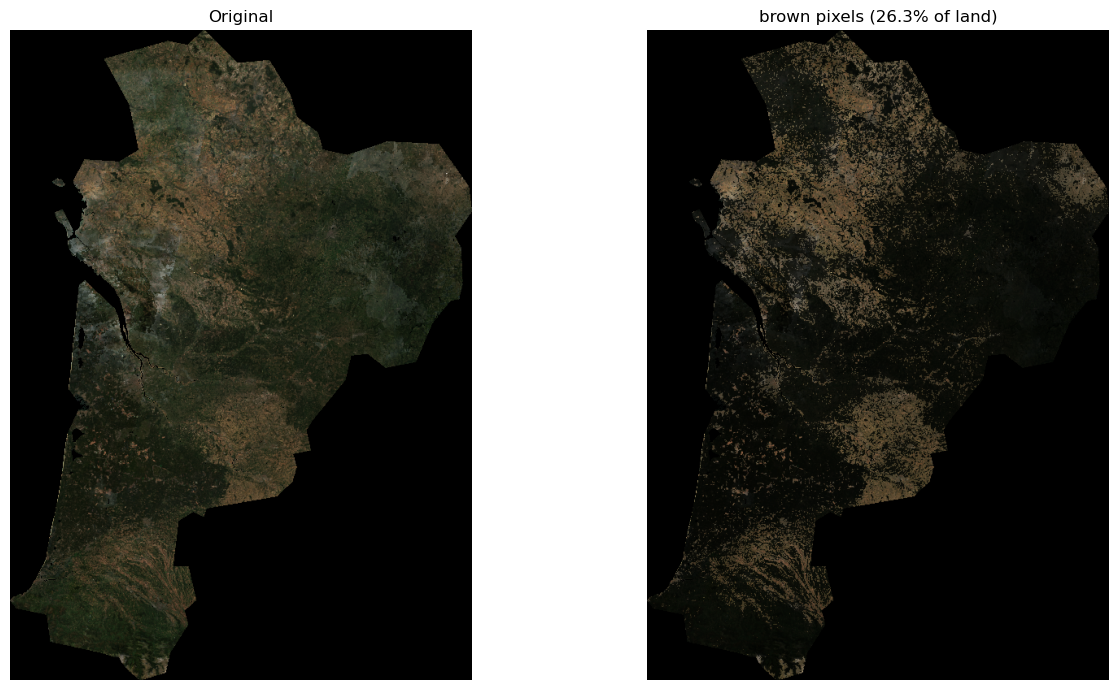

In [7]:
visualize_mask(index_df.iloc[50]["path"], kind="brown")

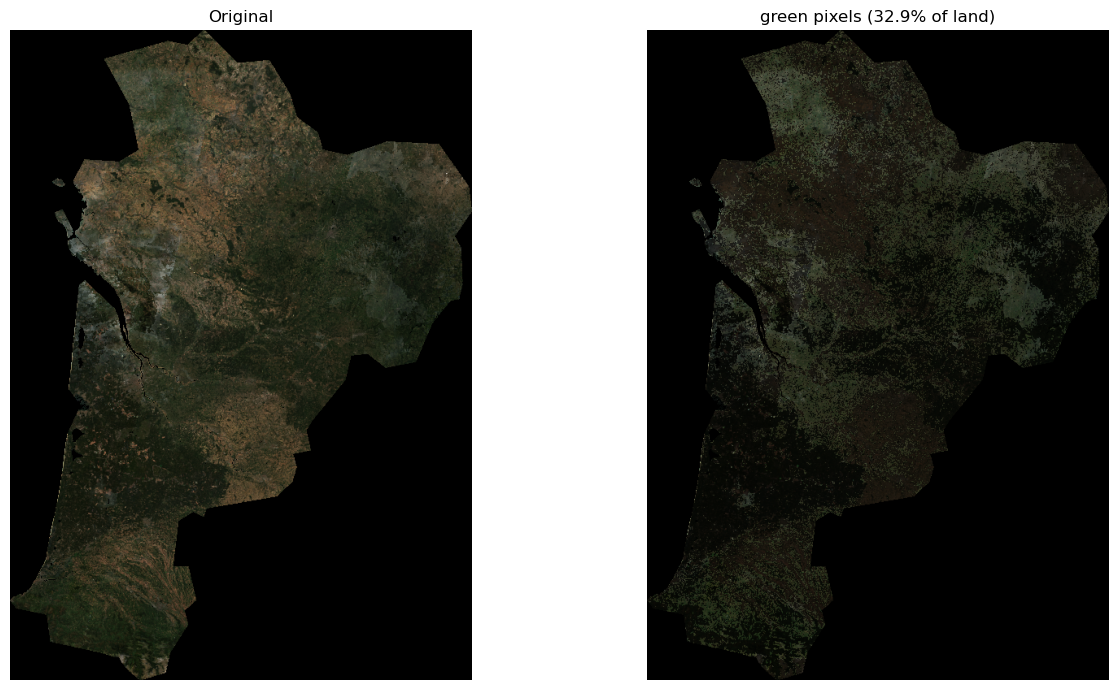

In [8]:
visualize_mask(index_df.iloc[50]["path"], kind="green")

## 5. Build the analysis DataFrame

Applies the same filter pattern as the average-colour notebook, then computes
green%, brown%, and the index.

In [9]:
def build_analysis_dataframe(months=None, years=None, regions=None, level=None,
                             output_dir=OUTPUT_DIR):
    df = scan_images(output_dir)
    if level is not None: df = df[df["level"] == level]
    if months:            df = df[df["month"].isin(months)]
    if years:             df = df[df["year"].isin(years)]
    if regions:           df = df[df["nuts_id"].isin(regions)]

    df = df.copy()
    df["green_pct"] = df["path"].apply(greenness)
    df["brown_pct"] = df["path"].apply(brownness)
    df["index"] = df["green_pct"] - df["brown_pct"]

    df["country"] = df["nuts_id"].str[:2]


    return df.reset_index(drop=True)


# Example: July 2024 for all countries
july_2024 = build_analysis_dataframe(months=[7], years=[2024], level=1)
july_2024.head(50)

,region,nuts_id,level,year,month,path,green_pct,brown_pct,index,country
0,FRI_Nouvelle-Aquitaine,FRI,1,2024,7,output/FRI_Nouvelle-Aquitaine/2024/FRI_Nouvell...,67.981853,12.315662,55.666190,FR
1,FRF_Grand Est,FRF,1,2024,7,output/FRF_Grand Est/2024/FRF_Grand Est_2024-0...,57.526040,24.866723,32.659317,FR
2,FRJ_Occitanie,FRJ,1,2024,7,output/FRJ_Occitanie/2024/FRJ_Occitanie_2024-0...,56.664648,20.093087,36.571560,FR
3,FRH_Bretagne,FRH,1,2024,7,output/FRH_Bretagne/2024/FRH_Bretagne_2024-07-...,72.448975,14.149410,58.299565,FR
4,FRM_Corse,FRM,1,2024,7,output/FRM_Corse/2024/FRM_Corse_2024-07-01.png,26.778629,25.462927,1.315703,FR
5,FRC_Bourgogne-Franche-Comté,FRC,1,2024,7,output/FRC_Bourgogne-Franche-Comté/2024/FRC_Bo...,61.239263,17.337996,43.901267,FR
6,FRE_Hauts-de-France,FRE,1,2024,7,output/FRE_Hauts-de-France/2024/FRE_Hauts-de-F...,51.720623,33.617688,18.102935,FR
7,FRB_Centre — Val de Loire,FRB,1,2024,7,output/FRB_Centre — Val de Loire/2024/FRB_Cent...,38.051539,41.267702,-3.216163,FR
8,FRL_Provence-Alpes-Côte d’Azur,FRL,1,2024,7,output/FRL_Provence-Alpes-Côte d’Azur/2024/FRL...,49.615036,27.840739,21.774297,FR
9,FRG_Pays de la Loire,FRG,1,2024,7,output/FRG_Pays de la Loire/2024/FRG_Pays de l...,68.775412,17.691000,51.084412,FR


## 6. Save / load CSVs

Scoring 1000+ images takes a few minutes — cache the results so you don't recompute
every time you re-open the notebook.

In [10]:
def save_csv(df, name):
    path = os.path.join(CSV_OUT_DIR, f"{name}.csv")
    df.to_csv(path, index=False)
    print(f"Saved {len(df)} rows to {path}")

def load_csv(name):
    return pd.read_csv(os.path.join(CSV_OUT_DIR, f"{name}.csv"))


# Example — compute once, cache:
# all_scores = build_analysis_dataframe()
# save_csv(all_scores, "all_scores")
# ...later...
# all_scores = load_csv("all_scores")

## 7. Visualizations

### 7a. Year × month heatmap for one region

Shows seasonality and year-over-year anomalies. Diverging colormap so brown reads as
brown and green as green.

In [11]:
def heatmap_region(df, nuts_id, metric="index", vmin=None, vmax=None):
    sub = df[df["nuts_id"] == nuts_id]
    if sub.empty:
        print(f"No data for {nuts_id}")
        return

    pivot = sub.pivot_table(index="year", columns="month", values=metric)

    cmap = "RdYlGn" if metric == "index" else ("Greens" if metric == "green_pct" else "YlOrBr")
    if metric == "index" and vmin is None:
        vabs = max(abs(pivot.min().min()), abs(pivot.max().max()))
        vmin, vmax = -vabs, vabs

    plt.figure(figsize=(12, max(3, 0.4 * len(pivot))))
    sns.heatmap(pivot, cmap=cmap, annot=True, fmt=".0f",
                vmin=vmin, vmax=vmax, cbar_kws={"label": metric})
    plt.title(f"{metric} — {nuts_id}")
    plt.xlabel("Month")
    plt.ylabel("Year")
    plt.show()


# Example: heatmap_region(all_scores, "ES30", metric="index")

### 7b. Time series across multiple regions

Compare drought signatures across a handful of NUTS units in one plot.

In [12]:
def time_series(df, nuts_ids, metric="index"):
    fig, ax = plt.subplots(figsize=(14, 6))
    for nuts_id in nuts_ids:
        sub = (df[df["nuts_id"] == nuts_id]
               .sort_values(["year", "month"]))
        if sub.empty:
            continue
        # Continuous x-axis: year + fractional month
        x = sub["year"] + (sub["month"] - 1) / 12
        ax.plot(x, sub[metric], marker="o", label=nuts_id, linewidth=1.2)

    ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
    ax.set_xlabel("Year")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} over time")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()


# Example: time_series(all_scores, ["ES30", "ES61", "PT17"], metric="index")

### 7c. Map of Europe coloured by greenness/brownness

Pass a DataFrame filtered to one snapshot (single month + year, or aggregated).

In [38]:
def plot_metric_map(df, metric="index", level=0, nuts_gdf=nuts_gdf,
                    title=None, vmin=None, vmax=None,
                    extent=(-13, 34, 30, 72), save_path=None):
    if df["nuts_id"].duplicated().any():
        raise ValueError("df has multiple rows per NUTS ID — filter or aggregate first")

    gdf = nuts_gdf[nuts_gdf["LEVL_CODE"] == level]
    merged = gdf.merge(df[["nuts_id", metric]],
                       left_on="NUTS_ID", right_on="nuts_id", how="inner")

    cmap = "RdYlGn" if metric == "index" else ("Greens" if metric == "green_pct" else "YlOrBr")
    if metric == "index" and vmin is None:
        vabs = max(abs(merged[metric].min()), abs(merged[metric].max()))
        vmin, vmax = -vabs, vabs
    elif metric == "anomaly":
        cmap = "RdYlGn"
        vabs = max(abs(merged[metric].min()), abs(merged[metric].max()))
        vmin, vmax = -vabs, vabs


    fig, ax = plt.subplots(figsize=(15, 15), subplot_kw={
        "projection": ccrs.LambertAzimuthalEqualArea(central_longitude=10, central_latitude=55)
    })
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.OCEAN, facecolor="white")
    ax.add_feature(cfeature.LAND.with_scale("50m"), facecolor="#f0f0f0")
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.5)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), edgecolor="#666", linewidth=0.3)

    merged.plot(ax=ax, column=metric, cmap=cmap, vmin=vmin, vmax=vmax,
                edgecolor="black", linewidth=0.3, legend=True,
                transform=ccrs.PlateCarree(),
                legend_kwds={"label": metric, "shrink": 0.5})

    if title:
        ax.set_title(title, fontsize=14)
    if save_path:
        plt.savefig(save_path, format=save_path.split(".")[-1], bbox_inches="tight")
    plt.show()

## 9. Usage examples

In [26]:
# Compute everything once — this is the slow step (a few minutes for ~1000 images)
#all_scores = build_analysis_dataframe()
#save_csv(all_scores, "all_scores")

all_scores = pd.read_csv("output/0_analysis_csv/all_scores.csv")

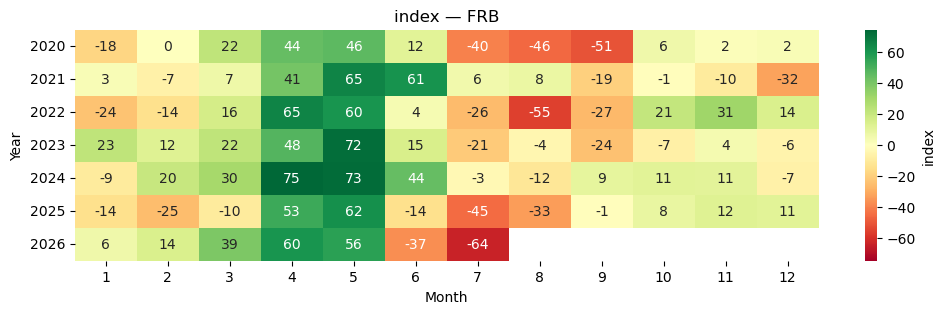

In [27]:
#Seasonality of Val Loire over the years
heatmap_region(all_scores, "FRB", metric="index")

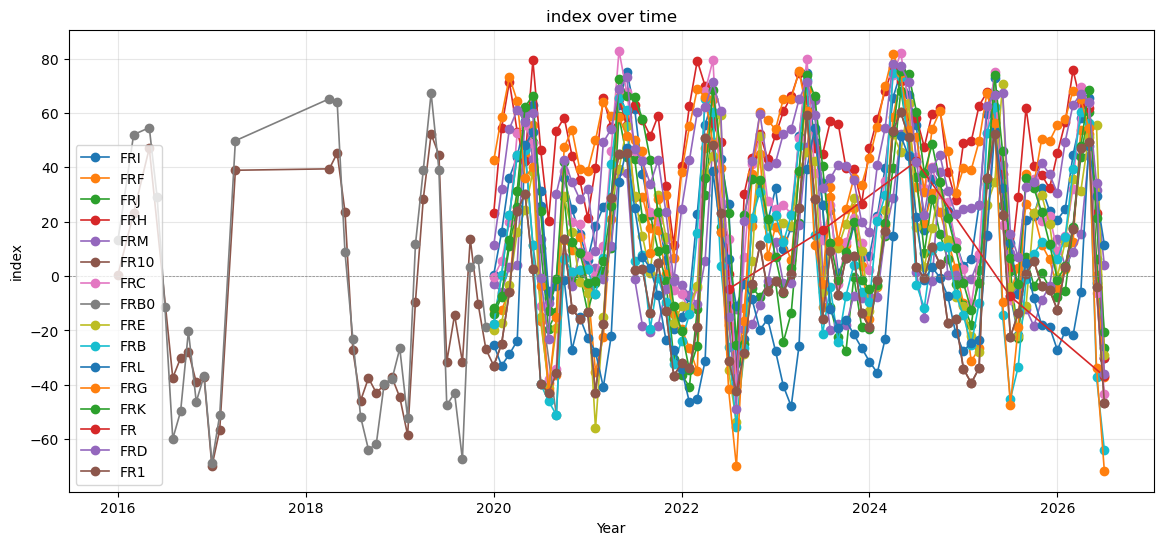

In [28]:
#select only French nuts 1 regions
france = all_scores[all_scores["country"] == "FR"]['nuts_id'].unique()
time_series(all_scores, france, metric="index")

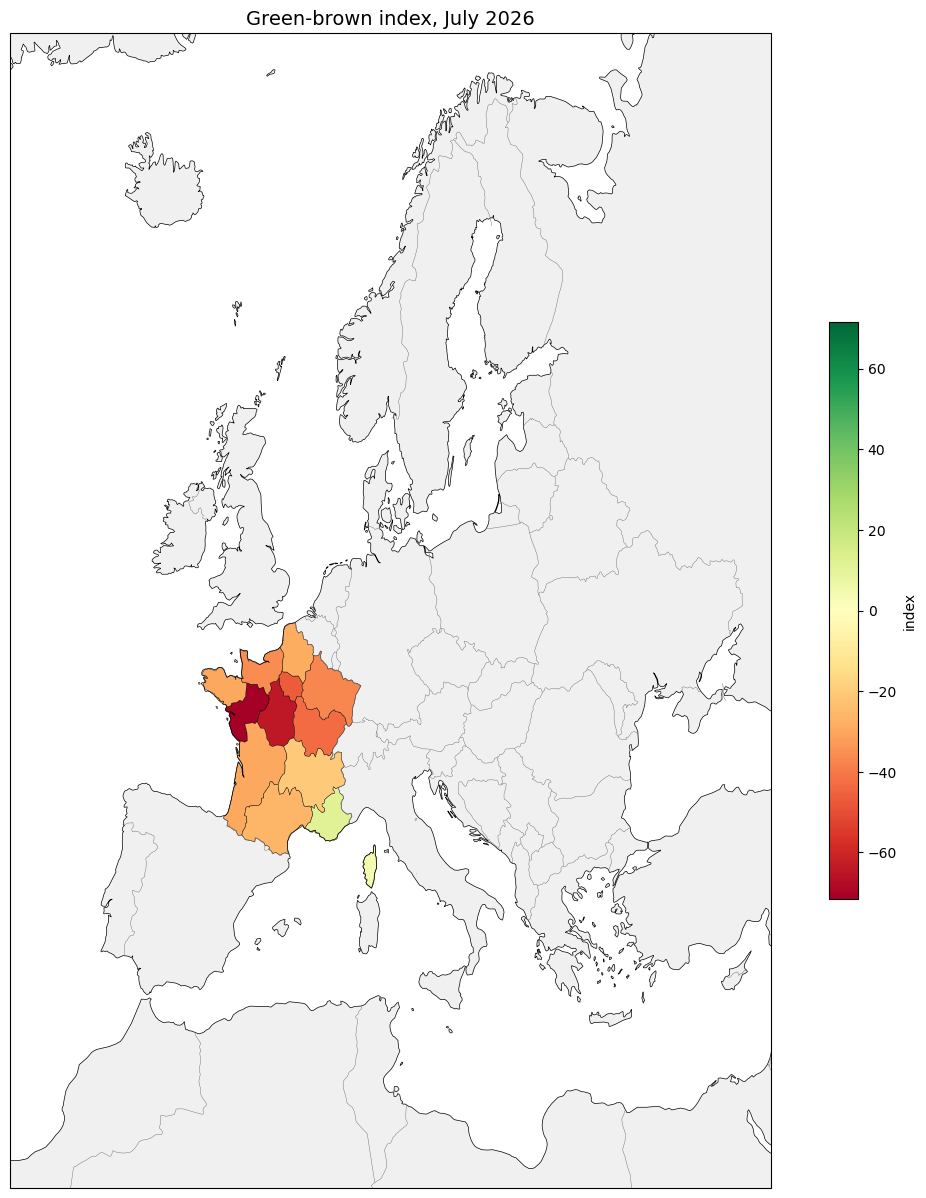

In [33]:
# C) Snapshot map: July 2026 across countries
snapshot = all_scores[(all_scores["year"] == 2026) &
                      (all_scores["month"] == 7) &
                      (all_scores["level"] == 1)]
plot_metric_map(snapshot, metric="index", level=1,
                title="Green-brown index, July 2026")

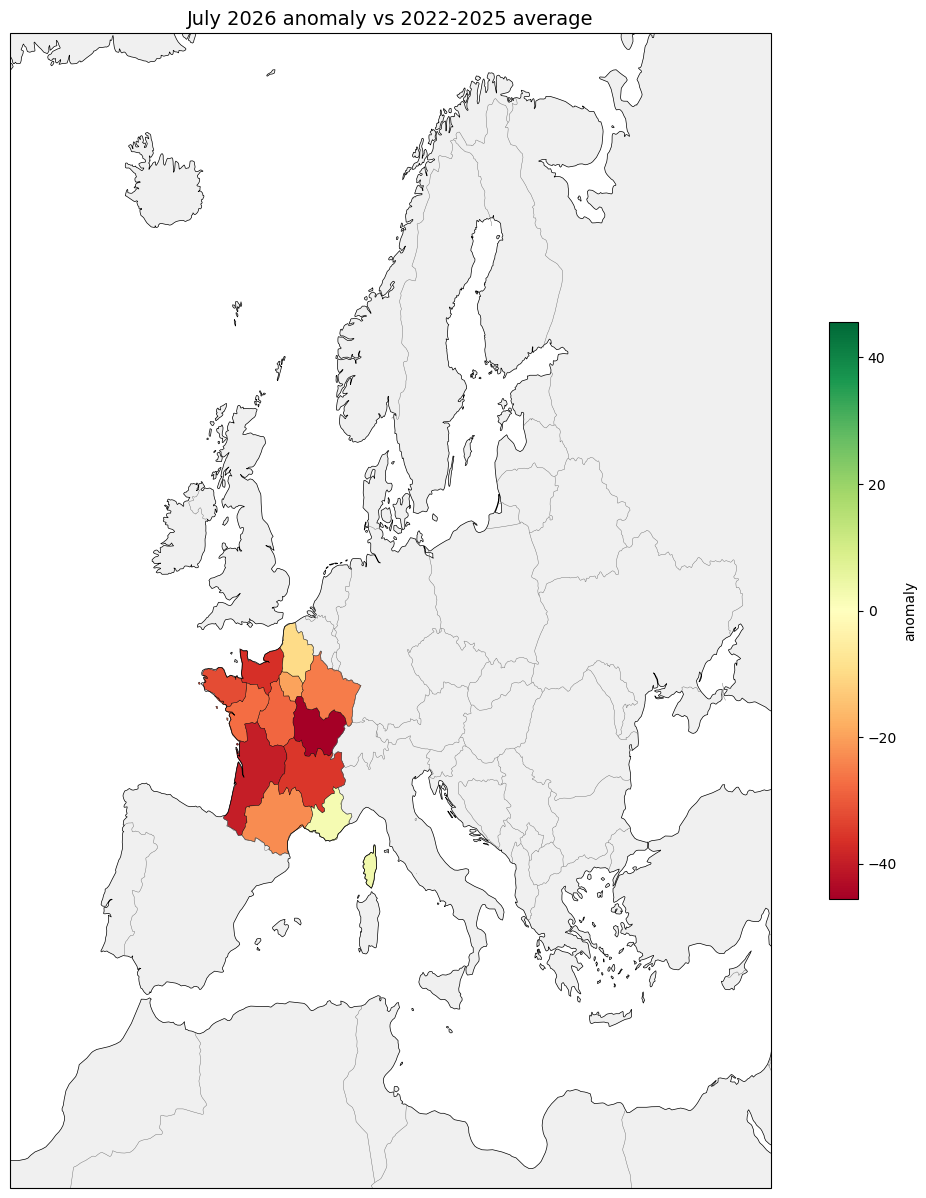

In [42]:
# E) Year-over-year anomaly: how much did July 2026 differ from the 2022-2025 baseline?
baseline_from = 2022
baseline_to = 2025
year = 2026
month = 7
nuts_level = 1

baseline = (all_scores[(all_scores["year"].isin([baseline_from, baseline_to])) &
                       (all_scores["month"] == month)]
            .groupby("nuts_id")["index"].mean().rename("baseline"))

target = all_scores[(all_scores["year"] == year) & (all_scores["month"] == month)].copy()
target = target.merge(baseline, on="nuts_id")
target["anomaly"] = target["index"] - target["baseline"]
plot_metric_map(target[target["level"] == nuts_level], metric="anomaly", level=nuts_level,
                title=f"July {year} anomaly vs {baseline_from}-{baseline_to} average")